# Aquaculture Water Quality Prediction

## 1. Importing Libraries

In [25]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings("ignore")

## 2. Loading the Dataset
We load the aquaculture dataset and take an initial look at its structure and contents.

In [26]:
df = pd.read_csv("aquaculture.csv")

In [27]:
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 500 rows × 25 columns


,Water Temperature,pH Levels,Dissolved Oxygen,Ammonia Concentration,Nitrite Concentration,Nitrate Concentration,Total Suspended Solids,Feed Rate,Fish Stocking Density,Water Flow Rate,...,Phosphorus Concentration,Lighting Intensity,Water Hardness,Microbial Activity,Fish Species Factor,Water Quality Index,Ammonia and Nitrite Levels,pH Stability,Algal Bloom Risk,Dissolved Oxygen Fluctuations
0,20.526730,7.395469,4.455485,0.592166,0.707792,23.105386,25.230432,444.028225,33.250172,150.305435,...,0.961774,3873.350180,160.831534,0.422236,1,3.064403,1.299958,15.242184,1162.488455,-21.070944
1,19.880464,7.972372,5.408596,0.244554,0.905584,37.357314,22.922653,309.474258,16.276731,141.250859,...,0.966045,19996.352287,96.940409,0.334271,0,3.500825,1.150138,6.225368,5999.368710,-11.692790
2,15.307001,7.567953,7.760424,1.193053,0.334020,40.731808,96.567373,90.996565,26.593416,325.092048,...,0.078146,2167.221569,294.508133,0.316503,1,4.069181,1.527072,6.065334,650.312412,0.551254
3,21.765728,7.387369,7.075700,1.061007,0.171467,6.393593,91.820939,214.433654,27.322735,210.659140,...,1.280603,9130.016824,157.659656,0.842687,1,3.850606,1.232474,6.868231,2739.565813,-6.378256
4,16.593009,7.713272,7.464499,0.091754,0.551352,8.617430,48.516681,222.310968,32.118359,154.475118,...,0.066115,8292.986084,226.717944,0.736690,0,4.109703,0.643107,10.751676,2488.000637,-6.862885


## 3. Exploratory Data Analysis (EDA)
Before building any model, we examine the data for missing values, duplicates, data types, and distributions.

In [28]:
# Column names
df.columns

Index(['Water Temperature', 'pH Levels', 'Dissolved Oxygen',
       'Ammonia Concentration', 'Nitrite Concentration',
       'Nitrate Concentration', 'Total Suspended Solids', 'Feed Rate',
       'Fish Stocking Density', 'Water Flow Rate', 'Biofilter Surface Area',
       'Water Exchange Rate', 'Carbon Dioxide', 'Alkalinity', 'Salinity',
       'Phosphorus Concentration', 'Lighting Intensity', 'Water Hardness',
       'Microbial Activity', 'Fish Species Factor', 'Water Quality Index',
       'Ammonia and Nitrite Levels', 'pH Stability', 'Algal Bloom Risk',
       'Dissolved Oxygen Fluctuations'],
      dtype='object')

In [29]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Water Temperature              500 non-null    float64
 1   pH Levels                      500 non-null    float64
 2   Dissolved Oxygen               500 non-null    float64
 3   Ammonia Concentration          500 non-null    float64
 4   Nitrite Concentration          500 non-null    float64
 5   Nitrate Concentration          500 non-null    float64
 6   Total Suspended Solids         500 non-null    float64
 7   Feed Rate                      500 non-null    float64
 8   Fish Stocking Density          500 non-null    float64
 9   Water Flow Rate                500 non-null    float64
 10  Biofilter Surface Area         500 non-null    float64
 11  Water Exchange Rate            500 non-null    float64
 12  Carbon Dioxide                 500 non-null    flo

In [30]:
# Missing value count and percentage
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing[missing["Missing Count"] > 0] if missing["Missing Count"].sum() > 0 else "✅ No missing values found")



✅ No missing values found


### 3.1 Feature Distributions
Histograms show the distribution of each numeric feature, helping us spot skewness or outliers.

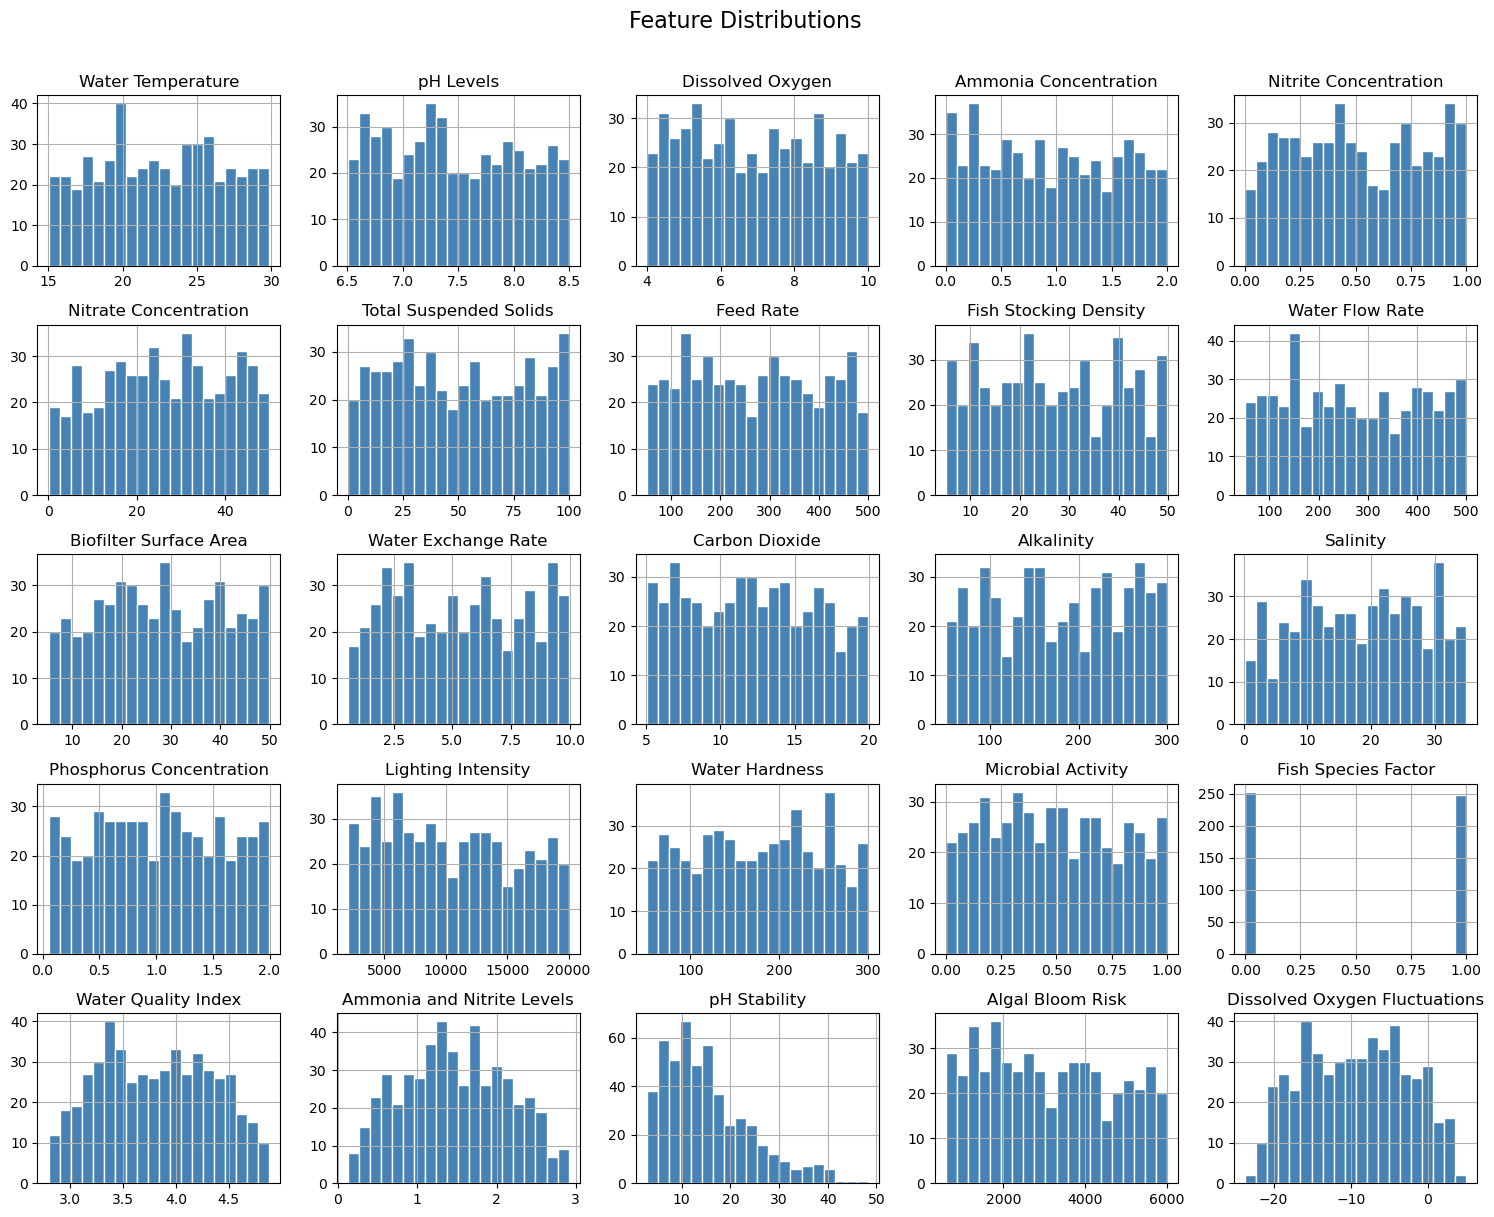

In [31]:
df.hist(figsize=(15, 12), bins=20, color="steelblue", edgecolor="white")
plt.suptitle("Feature Distributions", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Outlier Detection — Boxplots
Boxplots highlight outliers in individual features.

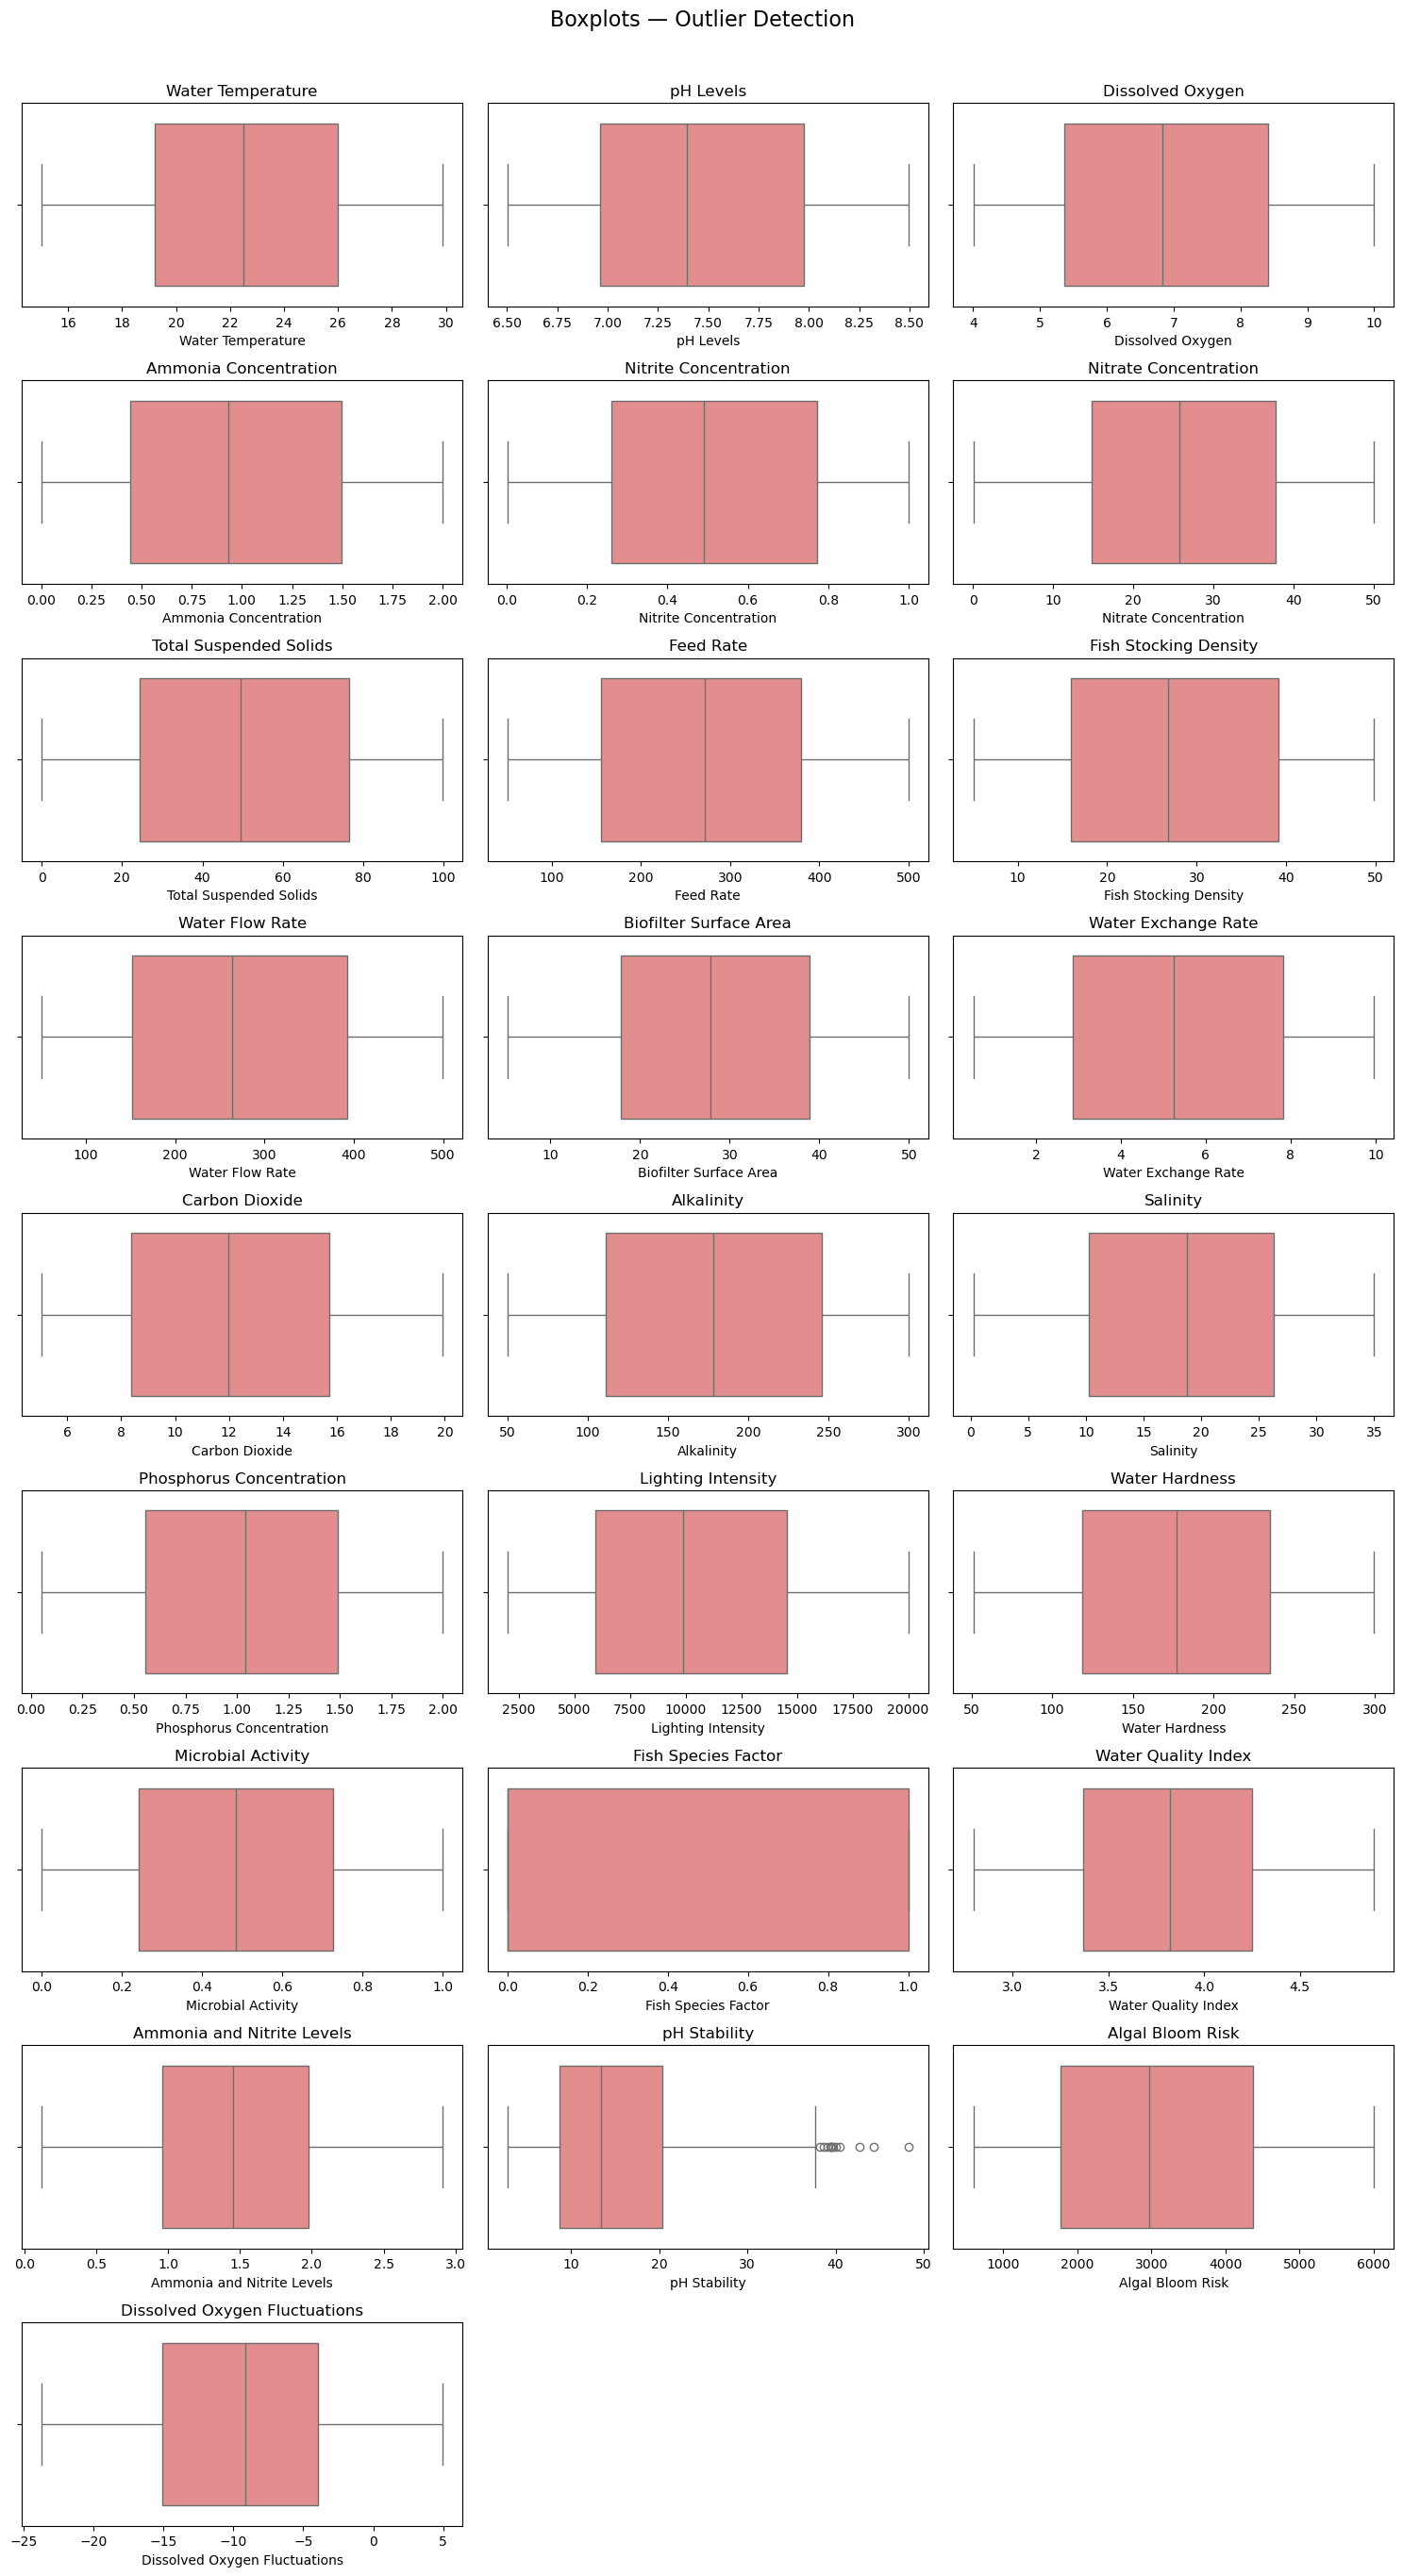

In [32]:
numeric_columns = df.select_dtypes(include=np.number).columns
n = len(numeric_columns)
fig, axes = plt.subplots(nrows=(n + 2) // 3, ncols=3, figsize=(15, (n // 3 + 1) * 3))
axes = axes.flatten()
for i, col in enumerate(numeric_columns):
    sns.boxplot(x=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Boxplots — Outlier Detection", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Correlation Heatmap
Shows linear relationships between features. Highly correlated features may be redundant; features correlated with the target are useful predictors.

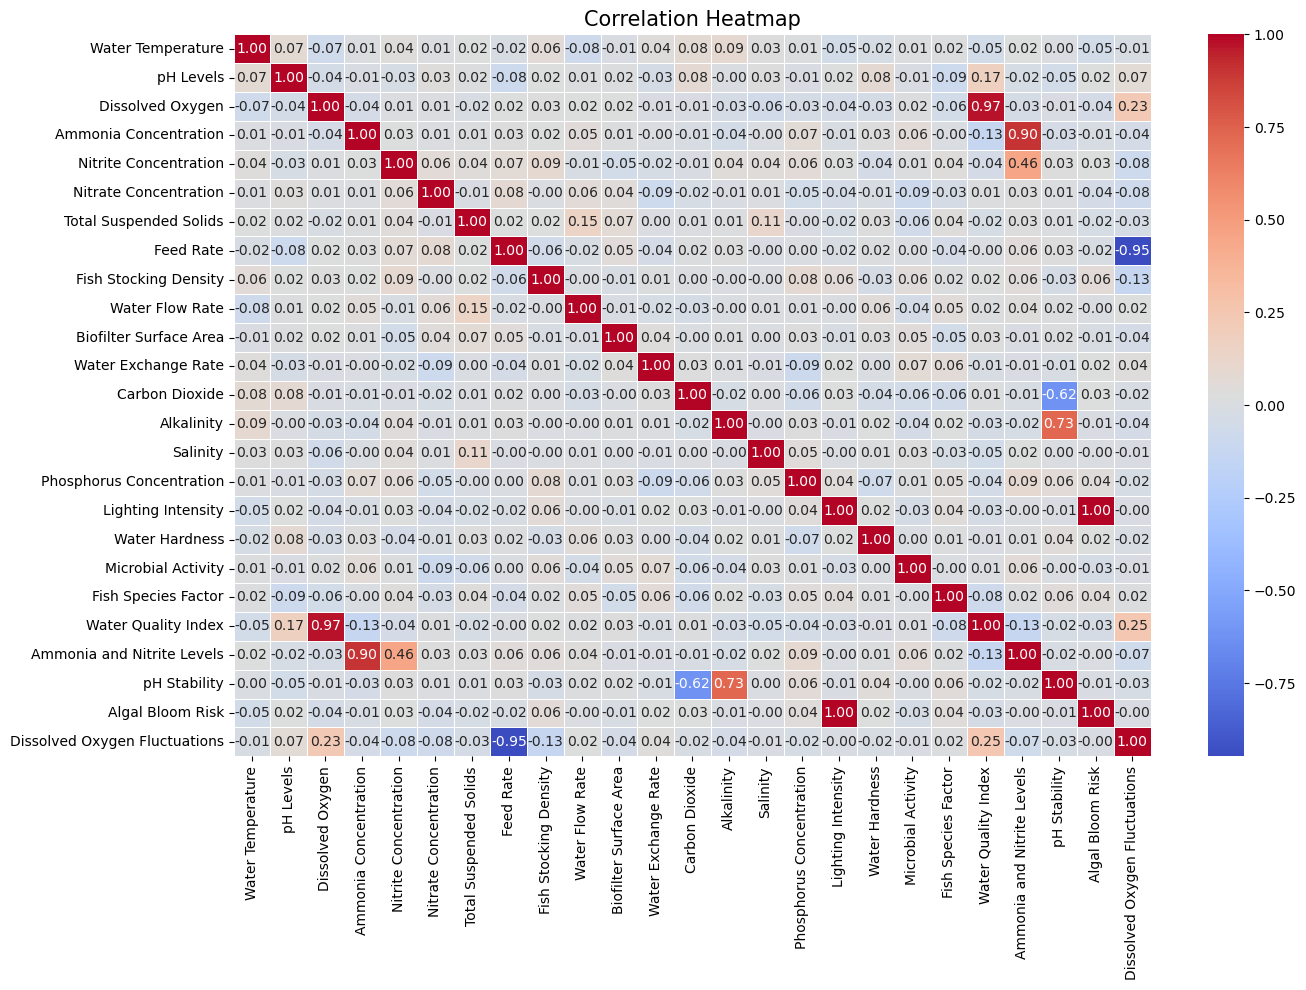

In [33]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=15)
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Data Splitting
We predict **Water Quality Index** and drop correlated target-leakage columns (, , ) that are derived from or directly related to the target.

In [34]:
TARGET = "Water Quality Index"
DROP_COLS = ["Water Quality Index", "Ammonia and Nitrite Levels", "pH Stability", "Algal Bloom Risk"]

X = df.drop(columns=DROP_COLS)
y = df[TARGET]

print("Features used:", list(X.columns))
print(f"X shape: {X.shape} | y shape: {y.shape}")

Features used: ['Water Temperature', 'pH Levels', 'Dissolved Oxygen', 'Ammonia Concentration', 'Nitrite Concentration', 'Nitrate Concentration', 'Total Suspended Solids', 'Feed Rate', 'Fish Stocking Density', 'Water Flow Rate', 'Biofilter Surface Area', 'Water Exchange Rate', 'Carbon Dioxide', 'Alkalinity', 'Salinity', 'Phosphorus Concentration', 'Lighting Intensity', 'Water Hardness', 'Microbial Activity', 'Fish Species Factor', 'Dissolved Oxygen Fluctuations']
X shape: (500, 21) | y shape: (500,)


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (400, 21) | Test: (100, 21)


In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 5. Model Comparison
compare them on MAE, RMSE, R² Score, and MAPE.

In [37]:
models = {
    "Linear Regression":   LinearRegression(),
    "Decision Tree":       DecisionTreeRegressor(random_state=42),
    "Random Forest":       RandomForestRegressor(random_state=42),
    "Gradient Boosting":   GradientBoostingRegressor(random_state=42),
    "XGBoost":             XGBRegressor(random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "MAE":      round(mean_absolute_error(y_test, pred), 4),
        "RMSE":     round(np.sqrt(mean_squared_error(y_test, pred)), 4),
        "R2 Score": round(r2_score(y_test, pred), 4),
        "MAPE":     round(np.mean(np.abs((y_test - pred) / y_test)) * 100, 4)
    })

result_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False).reset_index(drop=True)
result_df

,Model,MAE,RMSE,R2 Score,MAPE
0,Linear Regression,0.0140,0.0190,0.9988,0.3736
1,Gradient Boosting,0.0333,0.0405,0.9944,0.9142
2,XGBoost,0.0523,0.0637,0.9862,1.4215
3,Random Forest,0.0599,0.0730,0.9819,1.6204
4,Decision Tree,0.0923,0.1104,0.9587,2.4759


In [38]:
best_model = result_df.iloc[0]

print(best_model)

Model       Linear Regression
MAE                     0.014
RMSE                    0.019
R2 Score               0.9988
MAPE                   0.3736
Name: 0, dtype: object


## 6. Hyperparameter Tuning — Random Forest

In [39]:
RandomForestRegressor()

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestRegressor

In [40]:
param_grid = {
    "n_estimators":    [100, 200, 300],
    "max_depth":       [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4]
}

In [42]:
rf = RandomForestRegressor(random_state=42)

In [43]:
grid_search = GridSearchCV(

    estimator=rf,

    param_grid=param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1,

    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [44]:
print("Best Parameters")

print(grid_search.best_params_)

Best Parameters
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [45]:
best_rf = grid_search.best_estimator_

In [46]:
prediction = best_rf.predict(X_test)

In [23]:
# Randomized Search (faster alternative)
random_search = RandomizedSearchCV(rf, param_grid, cv=5, n_iter=20, scoring="r2", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
print("RandomizedSearchCV Best Parameters:", random_search.best_params_)

RandomizedSearchCV Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 15}


## 7. Final Model Evaluation

In [47]:
mae = mean_absolute_error(y_test,prediction)

rmse = np.sqrt(mean_squared_error(y_test,prediction))

r2 = r2_score(y_test,prediction)

print("MAE :",mae)

print("RMSE :",rmse)

print("R2 :",r2)

MAE : 0.06085247123809267
RMSE : 0.07279038435022628
R2 : 0.9820243248920343


In [48]:
scores = cross_val_score(

    best_rf,

    X,

    y,

    cv=5,

    scoring="r2"
)

In [49]:
print(scores)

print(scores.mean())

[0.98856765 0.98361878 0.98419808 0.98549712 0.98587569]
0.9855514626903135


### Actual vs Predicted Plot

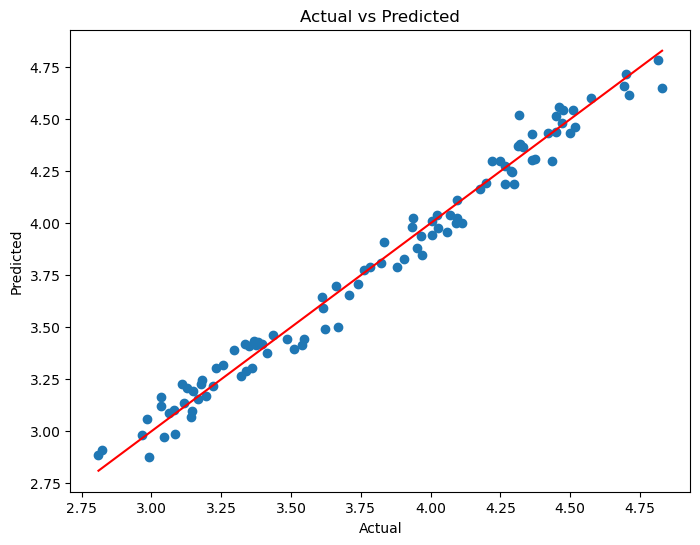

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test,prediction)

plt.plot(

    [y_test.min(),y_test.max()],

    [y_test.min(),y_test.max()],

    color="red"

)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

In [50]:
import joblib

joblib.dump(best_rf,"best_model.pkl")

['best_model.pkl']